# Занятие 2. Семинар: линейная регрессия

На лекции была разобрана линейная регрессия: как найти веса, можно ли им
верить и откуда в функции потерь берутся квадраты. Сегодня проходим те же идеи
в том же порядке на знакомых данных и смотрим, как каждая из них проявляется
в числах.

Датасет тот же, что на первом занятии, но задача другая: вместо сорта
предсказываем **крепость вина** по остальным двенадцати признакам. Если какой-то
термин непонятен, он есть в словаре курса, `terminology/glossary.md`.

**Как работать с ноутбуком.** Ячейки идут по порядку, запускать сверху вниз.
В ячейках с многоточиями код пишем вместе на паре. Сразу за каждой такой
ячейкой идет проверка: если она отработала и напечатала, что все в порядке,
можно идти дальше.

## 0. Подготовка

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.dummy import DummyRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso, LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42

## 1. Задача: предсказать крепость

Объект — одно вино, признаки — двенадцать результатов химического анализа,
целевая переменная — крепость в процентах. Ответ здесь число, а не метка
из набора, поэтому это задача регрессии.

In [2]:
wine = load_wine(as_frame=True)
data = wine.frame.drop(columns="target")

y = data["alcohol"].to_numpy()
features = data.drop(columns="alcohol")
feature_names = list(features.columns)
X = features.to_numpy()

print("объектов:", X.shape[0], " признаков:", X.shape[1])
print(f"крепость: от {y.min():.2f} до {y.max():.2f}, среднее {y.mean():.2f}, "
      f"стандартное отклонение {y.std():.2f}")

объектов: 178  признаков: 12
крепость: от 11.03 до 14.83, среднее 13.00, стандартное отклонение 0.81


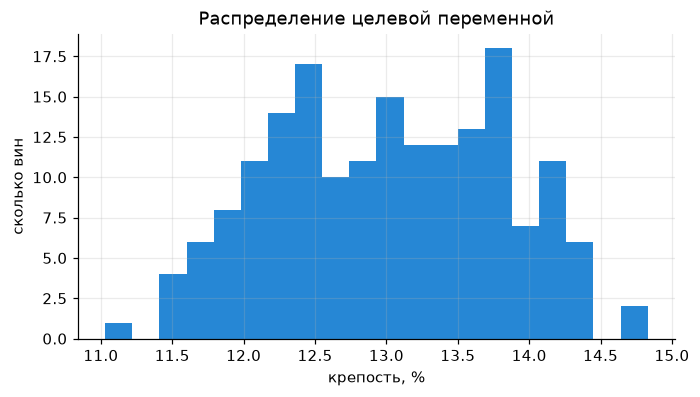

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(y, bins=20, color="#0072CE", alpha=0.85)
ax.set_xlabel("крепость, %")
ax.set_ylabel("сколько вин")
ax.set_title("Распределение целевой переменной")
plt.show()

Делим данные так же, как на первом занятии, но без параметра `stratify`.
Он сохраняет доли классов, а у непрерывной целевой переменной классов нет.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
proline_idx = feature_names.index("proline")

print("train:", X_train.shape, " test:", X_test.shape)

train: (124, 12)  test: (54, 12)


## 2. Baseline и метрики регрессии

В классификации мы считали долю верных ответов. В регрессии ответ почти
никогда не совпадает с правильным до последнего знака, поэтому смотрят
на величину ошибки. Пусть $y_i$ — настоящая крепость, $\hat{y}_i$ — предсказанная.

**MSE**, средний квадрат ошибки:
$$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**RMSE** — корень из MSE. Измеряется в тех же единицах, что и целевая
переменная, то есть в процентах крепости, и поэтому читается проще всех.

**MAE**, средний модуль ошибки:
$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**R²**, коэффициент детерминации: какую долю разброса целевой переменной
объясняет модель.
$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

Числитель — ошибка модели, знаменатель — ошибка модели, которая всегда
отвечает средним. Поэтому у такой модели $R^2 = 0$, у идеальной $R^2 = 1$,
а у модели хуже среднего он становится отрицательным.

Baseline для регрессии — всегда отвечать средней крепостью обучающей выборки.

In [5]:
base_model = DummyRegressor(strategy="mean")
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_mae = mean_absolute_error(y_test, y_pred_base)
base_r2 = r2_score(y_test, y_pred_base)

print(f"baseline: RMSE {base_rmse:.3f}, MAE {base_mae:.3f}, R2 {base_r2:.3f}")

baseline: RMSE 0.743, MAE 0.649, R2 -0.028


In [6]:
# --- проверка ---

# 1. модель отвечает одним и тем же числом, и это среднее обучающей выборки
assert np.allclose(y_pred_base, y_train.mean()), "baseline должен всегда отвечать средним трейна"

# 2. RMSE пересчитывается по формуле
expected = np.sqrt(np.mean((y_test - y_train.mean()) ** 2))
assert np.isclose(base_rmse, expected), f"ожидали RMSE {expected:.4f}, получили {base_rmse:.4f}"

# 3. MAE положительна и не больше RMSE: так бывает всегда
assert 0 < base_mae <= base_rmse, "MAE должна быть положительной и не больше RMSE"

# 4. R2 у модели «всегда среднее» около нуля
assert -0.2 < base_r2 < 0.05, f"R2 константной модели должен быть около нуля, получили {base_r2:.3f}"

print("проверки пройдены")

проверки пройдены


Модель, которая ничего не знает про вино, ошибается в среднем на три четверти
процента крепости. R² у нее чуть меньше нуля: среднее посчитано по обучающей
выборке, а проверяем на тестовой, где среднее немного другое.

## 3. Одна прямая: крепость от пролина

Начнем с самой простой модели — одного признака. Из всех признаков сильнее
всего с крепостью связан пролин.

$$\hat{y} = w \cdot x + b$$

Здесь $x$ — содержание пролина, $w$ — наклон прямой, $b$ — сдвиг.
Обучение сводится к выбору двух чисел.

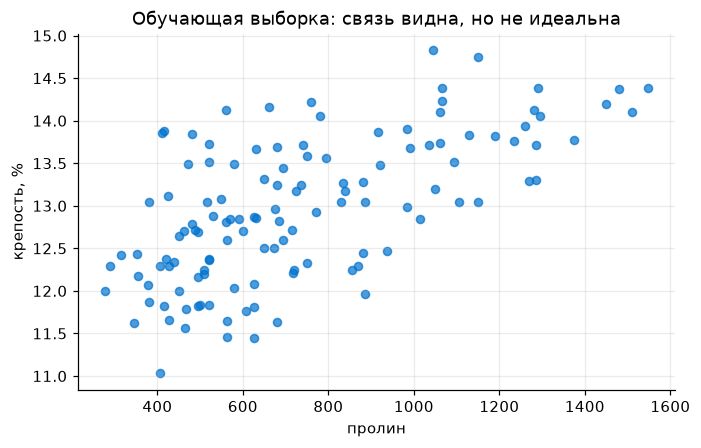

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(X_train[:, proline_idx], y_train, s=28, color="#0072CE", alpha=0.7)
ax.set_xlabel("пролин")
ax.set_ylabel("крепость, %")
ax.set_title("Обучающая выборка: связь видна, но не идеальна")
plt.show()

In [ ]:
X_train_1d = X_train[:, [proline_idx]]
X_test_1d = X_test[:, [proline_idx]]

model_1d = LinearRegression()
model_1d.fit(X_train_1d, y_train)

slope = model_1d.coef_[0]
intercept = model_1d.intercept_

y_pred_1d = model_1d.predict(X_test_1d)
rmse_1d = np.sqrt(mean_squared_error(y_test, y_pred_1d))
r2_1d = r2_score(y_test, y_pred_1d)

print(f"наклон {slope:.5f}, сдвиг {intercept:.3f}")
print(f"RMSE {rmse_1d:.3f}, R2 {r2_1d:.3f}")

наклон 0.00176, сдвиг 11.663
RMSE 0.561, R2 0.413


In [14]:
# --- проверка ---

# 1. прямая одна, значит и вес один
assert model_1d.coef_.shape == (1,), "у модели на одном признаке должен быть один вес"

# 2. наклон совпадает с тем, что дает обычная подгонка прямой
reference_slope, reference_intercept = np.polyfit(X_train[:, proline_idx], y_train, 1)
assert np.isclose(slope, reference_slope), "наклон не совпал с np.polyfit"
assert np.isclose(intercept, reference_intercept), "сдвиг не совпал с np.polyfit"

# 3. связь положительная: больше пролина — крепче вино
assert slope > 0, "наклон должен быть положительным"

# 4. одна прямая уже лучше константы
assert rmse_1d < base_rmse, "модель на пролине должна обыграть baseline"

print("проверки пройдены")

проверки пройдены


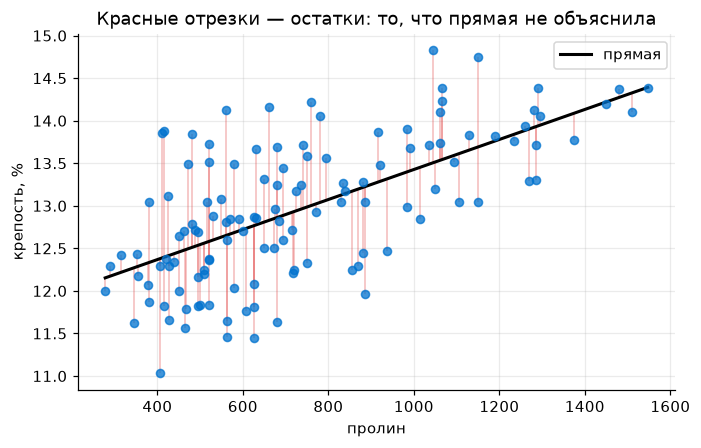

на каждую тысячу единиц пролина крепость в среднем растет на 1.76 процента


In [15]:
grid = np.linspace(X_train[:, proline_idx].min(), X_train[:, proline_idx].max(), 100)

fig, ax = plt.subplots(figsize=(7, 4.2))
x_points = X_train[:, proline_idx]
fitted = model_1d.predict(x_points[:, None])
ax.vlines(x_points, fitted, y_train, color="#E03A3A", alpha=0.35, lw=1)
ax.scatter(x_points, y_train, s=28, color="#0072CE", alpha=0.75, zorder=3)
ax.plot(grid, model_1d.predict(grid[:, None]), color="black", lw=2, label="прямая")
ax.set_xlabel("пролин")
ax.set_ylabel("крепость, %")
ax.set_title("Красные отрезки — остатки: то, что прямая не объяснила")
ax.legend()
plt.show()

print(f"на каждую тысячу единиц пролина крепость в среднем растет на {slope * 1000:.2f} процента")

Прямая объясняет около сорока процентов разброса крепости. Красные отрезки —
**остатки**: разности между настоящей крепостью и тем, что предсказала прямая.
Среди всех возможных прямых метод выбрал ту, у которой сумма квадратов этих
отрезков наименьшая. Почему квадратов, а не модулей, разберем ближе к концу семинара,
когда все остальное уже будет на месте.

## 4. Все признаки и нормальное уравнение

Теперь двенадцать признаков. Добавим к таблице столбец из единиц — тогда
сдвиг $b$ станет просто еще одним весом, и модель запишется одним произведением:

$$\hat{y} = X w$$

Функция потерь — квадрат длины вектора остатков. Она зависит и от данных,
и от весов, но при обучении данные зафиксированы, а подбираются только веса:

$$Q(X, w) = \frac{1}{n}\|y - Xw\|^2$$

Приравниваем градиент к нулю:

$$\nabla_w Q(X, w) = -\frac{2}{n}X^\top(y - Xw) = 0
\quad\Longrightarrow\quad
X^\top X\, w = X^\top y
\quad\Longrightarrow\quad
w = (X^\top X)^{-1} X^\top y$$

Это **нормальное уравнение**: веса получаются одной формулой, без итераций.

In [16]:
model_full = LinearRegression()
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)

full_rmse = np.sqrt(mean_squared_error(y_test, y_pred_full))
full_r2 = r2_score(y_test, y_pred_full)

print(f"все признаки: RMSE {full_rmse:.3f}, R2 {full_r2:.3f}")

все признаки: RMSE 0.449, R2 0.624


In [17]:
# --- проверка ---

# 1. по весу на каждый из двенадцати признаков
assert model_full.coef_.shape == (12,), "весов должно быть двенадцать"

# 2. больше признаков — меньше ошибка, чем у одной прямой
assert full_rmse < rmse_1d, "модель на всех признаках должна обыграть модель на пролине"

# 3. и R2 заметно выше
assert 0.5 < full_r2 < 0.75, f"R2 ожидался в районе 0.6, получили {full_r2:.3f}"

# 4. предсказаний столько же, сколько вин в тесте
assert y_pred_full.shape == y_test.shape, "не совпало число предсказаний"

print("проверки пройдены")

проверки пройдены


### Проверим формулу руками

Посчитаем веса по нормальному уравнению и сравним с библиотекой. Вместо явного
обращения матрицы используем `np.linalg.solve`: результат тот же, а считается
точнее и быстрее.

In [ ]:
# матрица признаков со столбцом единиц для свободного члена
X_ones = np.column_stack([np.ones(len(X_train)), X_train])

w_normal = np.linalg.solve(
    X_ones.T @ X_ones,
    X_ones.T @ y_train
)

print("сдвиг совпадает со sklearn:", np.isclose(w_normal[0], model_full.intercept_))
print("веса совпадают со sklearn: ", np.allclose(w_normal[1:], model_full.coef_))

сдвиг совпадает со sklearn: True
веса совпадают со sklearn:  True


### Геометрия: предсказание — это проекция

Нормальное уравнение можно переписать как $X^\top(y - Xw) = 0$. Это значит,
что вектор остатков перпендикулярен каждому столбцу таблицы. Предсказание $Xw$ —
ближайшая к $y$ точка среди всех линейных комбинаций признаков, то есть
проекция $y$ на пространство, натянутое на столбцы $X$.

In [24]:
residuals = y_train - X_ones @ w_normal
dots = X_ones.T @ residuals

print("скалярные произведения остатков со столбцами таблицы:")
print(np.round(dots, 8))

скалярные произведения остатков со столбцами таблицы:
[ 0. -0.  0. -0.  0. -0.  0.  0. -0. -0. -0. -0.  0.]


Все нули с точностью до округления: остатки действительно перпендикулярны
всем признакам и столбцу единиц. Из последнего, кстати, следует, что сумма
остатков равна нулю — линейная регрессия со сдвигом в среднем не завышает
и не занижает.

## 5. Градиентный спуск

Формула для весов есть, зачем что-то еще? Обращение матрицы $d \times d$
стоит порядка $d^3$ операций. Для двенадцати признаков это ничто, для
миллиона — невозможно. Кроме того, для многих моделей, которые пойдут дальше,
формулы нет вовсе.

Градиентный спуск ищет минимум шагами: на каждом шаге веса сдвигаются против
градиента функции потерь.

$$w \leftarrow w - \eta\, \nabla_w Q(X, w)$$

Здесь $\eta$ — шаг обучения. Слишком маленький — спуск идет вечно, слишком
большой — веса перепрыгивают минимум и разлетаются.

У градиентного спуска есть требование, которого нет у формулы: признаки должны
быть одного масштаба. Иначе допустимый шаг определяется самым крупным
признаком, и по остальным спуск не сдвинется.

In [ ]:
raw_sgd = SGDRegressor(random_state=SEED, max_iter=2000)
raw_sgd.fit(X_train, y_train)

raw_predictions = raw_sgd.predict(X_test)

print(f"без стандартизации предсказания доходят до {np.abs(raw_predictions).max():.2e}")
print("это при крепости от 11 до 15 процентов")

без стандартизации предсказания доходят до 1.25e+14
это при крепости от 11 до 15 процентов


In [26]:
raw_predictions

array([-1.04073460e+14, -9.63838538e+13, -9.42899399e+13, -8.41632563e+13,
       -7.77993919e+13, -1.01039442e+14, -8.48205210e+13, -9.83408316e+13,
       -8.95200034e+13, -8.26487471e+13, -8.77031425e+13, -1.25192722e+14,
       -7.69030458e+13, -8.06365777e+13, -9.07634989e+13, -9.26932002e+13,
       -9.00757258e+13, -7.78194206e+13, -8.25067337e+13, -8.84243786e+13,
       -7.78720081e+13, -7.49256474e+13, -9.35094130e+13, -1.12398916e+14,
       -8.70208523e+13, -8.92340760e+13, -1.12512050e+14, -9.22794732e+13,
       -8.05550075e+13, -1.01230461e+14, -8.06079197e+13, -9.46187583e+13,
       -9.47254568e+13, -8.13898381e+13, -6.72651501e+13, -8.34779453e+13,
       -9.82763496e+13, -9.93877453e+13, -8.32632460e+13, -8.86571745e+13,
       -8.24084833e+13, -9.54360917e+13, -9.82594402e+13, -1.01251097e+14,
       -9.11444088e+13, -8.39390289e+13, -9.00612543e+13, -1.09353815e+14,
       -9.95102616e+13, -7.42182609e+13, -8.57937583e+13, -1.03800758e+14,
       -7.40671636e+13, -

In [28]:
sgd_model.predict(X_test)

array([13.53215269, 13.7789058 , 12.70055387, 13.63375816, 12.64846159,
       13.81342635, 12.26160709, 13.17261193, 12.4512517 , 13.04159315,
       13.00780359, 12.95910468, 13.50876254, 12.4692459 , 14.28855227,
       12.06024669, 12.14878612, 12.27141696, 13.80372209, 12.16503244,
       14.90030528, 12.75842693, 12.71223769, 13.3785114 , 13.20016445,
       13.28230433, 11.83632728, 12.82301697, 12.2137455 , 13.45357252,
       13.3678189 , 11.73861473, 12.70410267, 14.20781273, 13.96447363,
       13.7885854 , 13.3993187 , 12.78984947, 12.80900792, 13.31270274,
       13.28906044, 11.83104893, 12.27112574, 12.67743404, 12.93443472,
       13.66959819, 12.79176088, 12.14298954, 12.684268  , 13.87214786,
       12.46108202, 13.50205451, 13.72574566, 13.47887643])

In [ ]:
sgd_model = make_pipeline(
    StandardScaler(),
    SGDRegressor(random_state=SEED, max_iter=2000, tol=1e-6),
)
sgd_model.fit(X_train, y_train)

sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_model.predict(X_test)))

print(f"градиентный спуск: RMSE {sgd_rmse:.3f}")
print(f"нормальное уравнение: RMSE {full_rmse:.3f}")

градиентный спуск: RMSE 0.450
нормальное уравнение: RMSE 0.449


In [29]:
# --- проверка ---

# 1. это конвейер, и в нем есть стандартизация
assert isinstance(sgd_model, Pipeline), "модель должна быть конвейером"
assert any(isinstance(step, StandardScaler) for step in sgd_model.named_steps.values()), (
    "в конвейере нет StandardScaler"
)

# 2. результат конечный: спуск не разлетелся
assert np.isfinite(sgd_rmse), "RMSE бесконечен, спуск разошелся"

# 3. и почти совпадает с точным решением
assert abs(sgd_rmse - full_rmse) <z 0.03, (
    f"градиентный спуск должен прийти туда же, куда формула: {sgd_rmse:.3f} против {full_rmse:.3f}"
)

print("проверки пройдены")

проверки пройдены


Со стандартизацией спуск приходит почти туда же, куда приводит формула.
Без нее — улетает в бесконечность.

## 6. Какая метрика что говорит

Соберем все модели вместе.

In [30]:
results = pd.DataFrame({
    "модель": ["baseline", "только пролин", "все признаки", "градиентный спуск"],
    "RMSE": [base_rmse, rmse_1d, full_rmse, sgd_rmse],
    "MAE": [
        base_mae,
        mean_absolute_error(y_test, y_pred_1d),
        mean_absolute_error(y_test, y_pred_full),
        mean_absolute_error(y_test, sgd_model.predict(X_test)),
    ],
    "R2": [
        base_r2, r2_1d, full_r2,
        r2_score(y_test, sgd_model.predict(X_test)),
    ],
}).set_index("модель")
results.round(3)

,RMSE,MAE,R2
модель,,,
baseline,0.743,0.649,-0.028
только пролин,0.561,0.461,0.413
все признаки,0.449,0.386,0.624
градиентный спуск,0.450,0.387,0.622


MSE и RMSE сильнее штрафуют большие ошибки: квадрат ошибки в два процента
в четыре раза больше квадрата ошибки в один процент. MAE ко всем ошибкам
относится одинаково. Проверим, что будет, если модель грубо ошибется
всего на трех винах из пятидесяти четырех.

In [32]:
spoiled = y_pred_full.copy()
spoiled[:3] += 3.0

for name, predictions in [("как есть", y_pred_full), ("три грубые ошибки", spoiled)]:
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    print(f"{name:18s} RMSE {rmse:.3f}   MAE {mae:.3f}")

как есть           RMSE 0.449   MAE 0.386
три грубые ошибки  RMSE 0.785   MAE 0.524


RMSE вырос намного сильнее MAE. Отсюда практическое правило. Если грубые
ошибки особенно дороги, смотрят на RMSE. Если в данных бывают выбросы, которые
не хочется переоценивать, — на MAE. R² не зависит от единиц измерения, поэтому
им удобно сравнивать задачи между собой, но он ничего не говорит о том,
на сколько процентов модель ошибается.

## 7. Что значат веса

Хочется посмотреть на веса и сказать, какие признаки важнее. Напрямую так
делать нельзя: вес пролина измеряется в процентах крепости на единицу пролина,
а пролин исчисляется тысячами. Вес оттенка — в процентах на единицу оттенка,
который меняется от половины до полутора. Числа несравнимы.

Решение то же, что для kNN и градиентного спуска: стандартизовать признаки. Тогда вес показывает,
на сколько процентов меняется крепость, если признак вырос на одно стандартное
отклонение.

In [33]:
scaled_model = make_pipeline(StandardScaler(), LinearRegression())
scaled_model.fit(X_train, y_train)

weights = scaled_model[-1].coef_
std_weights = pd.Series(weights, index=feature_names)
std_weights = std_weights.reindex(std_weights.abs().sort_values(ascending=False).index)

print(std_weights.round(3))

proline                         0.351
color_intensity                 0.348
malic_acid                      0.152
alcalinity_of_ash              -0.142
hue                             0.098
proanthocyanins                -0.089
flavanoids                      0.078
od280/od315_of_diluted_wines    0.056
ash                             0.053
magnesium                      -0.040
nonflavanoid_phenols           -0.026
total_phenols                  -0.006
dtype: float64


In [34]:
# --- проверка ---

# 1. стандартизация не меняет предсказаний линейной регрессии
assert np.allclose(scaled_model.predict(X_test), y_pred_full), (
    "предсказания должны совпасть с обычной регрессией: масштаб признаков "
    "меняет веса, но не саму прямую"
)

# 2. весов двенадцать, и у каждого имя признака
assert len(std_weights) == 12 and set(std_weights.index) == set(feature_names)

# 3. отсортированы по убыванию модуля
assert (np.diff(std_weights.abs().to_numpy()) <= 1e-12).all(), "веса не отсортированы по модулю"

# 4. два самых сильных признака
assert set(std_weights.index[:2]) == {"proline", "color_intensity"}, (
    f"ожидали пролин и интенсивность цвета, получили {list(std_weights.index[:2])}"
)

print("проверки пройдены")

проверки пройдены


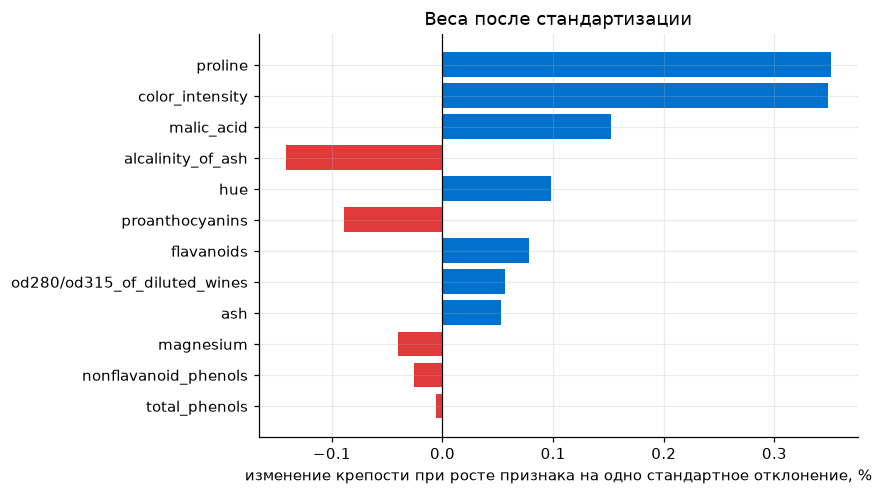

In [35]:
fig, ax = plt.subplots(figsize=(8, 4.6))
colors = ["#0072CE" if value > 0 else "#E03A3A" for value in std_weights]
ax.barh(std_weights.index[::-1], std_weights.to_numpy()[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("изменение крепости при росте признака на одно стандартное отклонение, %")
ax.set_title("Веса после стандартизации")
plt.tight_layout()
plt.show()

Самые крепкие вина — с высоким пролином и темным цветом. Но с интерпретацией
надо быть осторожным. Вес общих фенолов почти ноль, и это **не значит**, что
фенолы с крепостью не связаны. Флавоноиды — часть общих фенолов, эти признаки
сильно коррелируют, и информацию, которую несут оба, модель отдала одному.
Какому именно — дело случая, в чем мы сейчас и убедимся.

## 8. Когда весам нельзя верить

В седьмом разделе мы читали веса: самые большие у пролина и интенсивности
цвета, а вес общих фенолов почти ноль. Прежде чем делать из этого выводы,
нужно проверить две вещи: насколько точно посчитаны сами веса и насколько они
зависят от того, какие именно вина попали в обучение.

### Точность вычислений

В нормальном уравнении стоит обратная матрица $(X^\top X)^{-1}$. Насколько
точно ее можно посчитать, показывает **число обусловленности**: во сколько раз
относительная ошибка на входе может вырасти на выходе. Компьютер хранит числа
с конечной точностью: `float64` держит около 16 значащих цифр, `float32`,
в котором обычно обучают нейросети, — около 7. Если число обусловленности
порядка $10^k$, при обращении матрицы теряется до $k$ цифр.

Обратим $X^\top X$ в трех вариантах: признаки как есть; те же данные, но пролин
записан в микрограммах на литр вместо миллиграммов, то есть умножен на тысячу;
признаки после стандартизации. Точность видно по тому, насколько произведение
матрицы на посчитанную обратную отличается от единичной матрицы. В идеале
разница нулевая.

In [36]:
X_train_std = StandardScaler().fit_transform(X_train)
X_train_ug = X_train.copy()
X_train_ug[:, proline_idx] *= 1000     # тот же пролин в микрограммах на литр

# матрицы признаков со столбцом единиц, как в нормальном уравнении
X_ones = np.column_stack([np.ones(len(X_train)), X_train])
X_ones_ug = np.column_stack([np.ones(len(X_train)), X_train_ug])
X_ones_std = np.column_stack([np.ones(len(X_train)), X_train_std])


def inverse_error(M, dtype):
    # насколько произведение M на посчитанную обратную отличается от единичной
    M = M.astype(dtype)
    return np.abs(M @ np.linalg.inv(M) - np.eye(len(M), dtype=dtype)).max()


rows = []
for name, ones in [("признаки как есть", X_ones), ("пролин в мкг/л", X_ones_ug),
                   ("после стандартизации", X_ones_std)]:
    M = ones.T @ ones
    rows.append({
        "вариант": name,
        "число обусловленности": f"{np.linalg.cond(M):.1e}",
        "ошибка обратной, float64": f"{inverse_error(M, np.float64):.0e}",
        "ошибка обратной, float32": f"{inverse_error(M, np.float32):.0e}",
    })
pd.DataFrame(rows).set_index("вариант")

,число обусловленности,"ошибка обратной, float64","ошибка обратной, float32"
вариант,,,
признаки как есть,1.4e+08,2e-11,2e-02
пролин в мкг/л,1.4e+14,1e-08,5e+00
после стандартизации,4.7e+01,8e-16,2e-07


Смена единиц не меняет данные, но число обусловленности вырастает в миллион раз,
и в `float32` обратная матрица перестает быть обратной: произведение отличается
от единичной на целые единицы. У стандартизованных признаков число
обусловленности не зависит от единиц, и обращение точное даже в `float32`.
Так что стандартизация нужна не только градиентному спуску и чтению весов,
но и точности самой формулы. `LinearRegression` и `np.linalg.solve` не считают
обратную матрицу явно и потому устойчивее, но предел точности есть и у них.

После стандартизации число обусловленности 47, а не единица. Масштаб здесь
уже ни при чем: так проявляется связь между признаками.

### Мультиколлинеарность

Флавоноиды — часть общих фенолов, поэтому эти признаки сильно связаны.

In [37]:
phenols_idx = feature_names.index("total_phenols")
flavanoids_idx = feature_names.index("flavanoids")
pair_corr = np.corrcoef(X_train[:, phenols_idx], X_train[:, flavanoids_idx])[0, 1]
print(f"корреляция общих фенолов и флавоноидов на обучающей выборке: {pair_corr:.2f}")

корреляция общих фенолов и флавоноидов на обучающей выборке: 0.86


Если два признака почти одинаковы, модели все равно, как поделить вклад между
ними. Сумма их весов определяется данными хорошо, а каждый вес по отдельности —
плохо: небольшое изменение выборки может перекинуть вклад с одного признака
на другой. Тогда вывод «вес фенолов почти ноль, значит фенолы на крепость
не влияют» ничего не стоит.

Проверим. Других выборок вин у нас нет, поэтому сымитируем их бутстрэпом:
двести раз случайно выберем 124 обучающих вина с повторениями и каждый раз
обучим модель. Чтобы веса можно было нарисовать на плоскости, возьмем только
два связанных признака. Если бы весам можно было верить, облако получилось бы
маленьким.

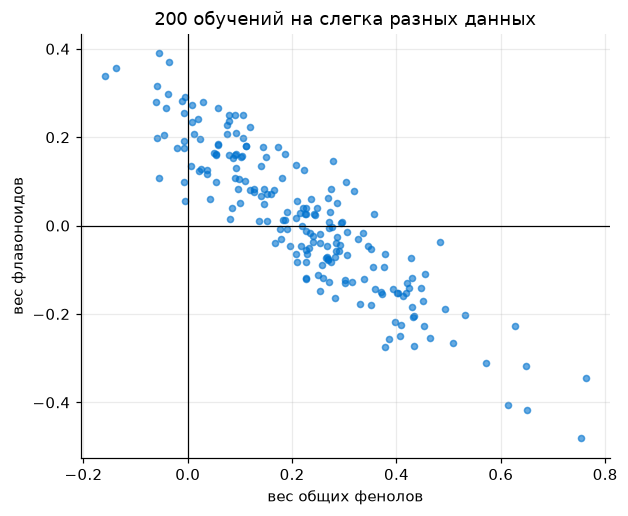

вес общих фенолов меняет знак в 10% обучений
вес флавоноидов меняет знак в 46% обучений

разброс веса фенолов 0.167, веса флавоноидов 0.163, их суммы 0.073
RMSE всех двухсот моделей на обучающей выборке: от 0.81 до 0.86


In [38]:
rng_boot = np.random.default_rng(SEED)
boot_idx = rng_boot.integers(0, len(y_train), size=(200, len(y_train)))
pair = X_train_std[:, [phenols_idx, flavanoids_idx]]

pair_models = [LinearRegression().fit(pair[i], y_train[i]) for i in boot_idx]
pair_ols = np.array([model.coef_ for model in pair_models])

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.scatter(pair_ols[:, 0], pair_ols[:, 1], s=16, color="#0072CE", alpha=0.6)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("вес общих фенолов")
ax.set_ylabel("вес флавоноидов")
ax.set_title("200 обучений на слегка разных данных")
plt.show()

flips = (np.sign(pair_ols) != np.sign(np.median(pair_ols, axis=0))).mean(axis=0)
print(f"вес общих фенолов меняет знак в {flips[0]:.0%} обучений")
print(f"вес флавоноидов меняет знак в {flips[1]:.0%} обучений")
print()

pair_rmse = [np.sqrt(mean_squared_error(y_train, model.predict(pair))) for model in pair_models]
print(f"разброс веса фенолов {pair_ols[:, 0].std():.3f}, веса флавоноидов {pair_ols[:, 1].std():.3f}, "
      f"их суммы {pair_ols.sum(axis=1).std():.3f}")
print(f"RMSE всех двухсот моделей на обучающей выборке: от {min(pair_rmse):.2f} до {max(pair_rmse):.2f}")

Облако вытянуто вдоль диагонали: когда один вес растет, другой падает.
Каждый вес разбросан сильно, разброс их суммы в два с лишним раза меньше,
а качество всех двухсот моделей почти одинаковое. Предсказывать связанность
признаков не мешает, а вот читать отдельные веса нельзя: в другой выборке вес
флавоноидов почти в половине случаев получил бы другой знак. Как с этим
справиться, разберем в десятом разделе.

## 9. Откуда берутся квадраты

В третьем разделе прямую выбирали по наименьшей сумме квадратов остатков.
Можно было бы складывать модули, а не квадраты. Выбор квадратов не произволен,
он следует из предположения о том, как устроен шум.

Предположим, что настоящая крепость — это прямая плюс случайная ошибка:

$$y_i = w x_i + b + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

Ошибки независимы и нормальны. Тогда вероятность увидеть именно такую
крепость у $i$-го вина при заданных $w$ и $b$ равна плотности нормального
распределения:

$$p(y_i \mid x_i, w, b) = \frac{1}{\sqrt{2\pi\sigma^2}}
  \exp\left(-\frac{(y_i - w x_i - b)^2}{2\sigma^2}\right)$$

Вина независимы, поэтому вероятность всей выборки — произведение по винам.
Это **правдоподобие**. Удобнее работать с его логарифмом:

$$\log L(w, b) = -\frac{n}{2}\log(2\pi\sigma^2)
  - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - w x_i - b)^2$$

Первое слагаемое от $w$ и $b$ не зависит. Второе стоит со знаком минус.
Значит **максимизировать правдоподобие — то же самое, что минимизировать
сумму квадратов остатков**. Метод наименьших квадратов — это метод
максимального правдоподобия при нормальном шуме.

Если бы шум был распределен не нормально, а по Лапласу, тот же вывод дал бы
сумму модулей, то есть MAE. Функция потерь — это предположение о шуме,
записанное формулой.

In [ ]:
x_points = X_train[:, proline_idx]
slopes = np.linspace(0, 2 * slope, 200)

mse_values, loglik_values = [], []
sigma2 = np.mean((y_train - model_1d.predict(x_points[:, None])) ** 2)
for w in slopes:
    b = y_train.mean() - w * x_points.mean()
    residuals = y_train - (w * x_points + b)
    mse_values.append(np.mean(residuals ** 2))
    loglik_values.append(
        -len(y_train) / 2 * np.log(2 * np.pi * sigma2)
        - np.sum(residuals ** 2) / (2 * sigma2)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(slopes, mse_values, color="#0072CE")
axes[0].set_title("MSE: ищем минимум")
axes[1].plot(slopes, loglik_values, color="#0F1418")
axes[1].set_title("логарифм правдоподобия: ищем максимум")
for ax in axes:
    ax.axvline(slope, ls="--", color="#E03A3A", lw=1.2)
    ax.set_xlabel("наклон w")
plt.tight_layout()
plt.show()

print("наклон с минимальным MSE:          ", round(slopes[np.argmin(mse_values)], 6))
print("наклон с максимальным правдоподобием:", round(slopes[np.argmax(loglik_values)], 6))

## 10. Регуляризация

В восьмом разделе веса связанных признаков прыгали от выборки к выборке. Та же
вероятностная логика, что объяснила квадраты, подсказывает, как это исправить.

До сих пор мы искали веса, при которых данные наиболее вероятны. Добавим
предположение о самих весах еще до того, как увидели данные: они скорее
маленькие, $w_j \sim \mathcal{N}(0, \tau^2)$. Это **априорное распределение**.

По теореме Байеса апостериорная вероятность весов пропорциональна
правдоподобию, умноженному на априорную:

$$p(w \mid X, y) \propto p(y \mid X, w)\, p(w)$$

Берем логарифм и ищем максимум. Правдоподобие дает сумму квадратов остатков,
а нормальное априорное распределение — сумму квадратов весов:

$$\log p(w \mid X, y) = -\frac{1}{2\sigma^2}\|y - Xw\|^2
  - \frac{1}{2\tau^2}\|w\|^2 + \text{const}$$

Умножим на $2\sigma^2 / n$ и сменим знак: максимум превращается в минимум
функции потерь со штрафом за большие веса:

$$Q(X, w) = \frac{1}{n}\|y - Xw\|^2 + \lambda\|w\|^2, \qquad \lambda = \frac{\sigma^2}{n\tau^2}$$

Такая оценка называется **MAP**, а штраф — **L2-регуляризацией**. Чем сильнее
мы уверены, что веса маленькие, тем меньше $\tau$ и тем сильнее штраф. Решение
меняется ровно в одном месте:

$$w = (X^\top X + n\lambda I)^{-1} X^\top y$$

Добавка $n\lambda I$ поднимает все собственные числа матрицы на $n\lambda$,
и она перестает быть почти вырожденной. В sklearn это `Ridge`; функция потерь
там записана без множителя $1/n$, поэтому сила штрафа `alpha` соответствует $n\lambda$.

Если взять вместо нормального априорного распределение Лапласа, получится
штраф за сумму модулей, $\lambda\sum_j |w_j|$. Это **L1-регуляризация**,
`Lasso`. У распределения Лапласа острый пик в нуле: ровно нулевой вес для него
вероятен, поэтому L1 не просто уменьшает веса, а обнуляет часть из них.

Нормальное априорное подходит, когда на ответ влияет много признаков понемногу,
как на цену квартиры. Лапласа — когда из многих признаков важны единицы, как
несколько слов из десятков тысяч в фильтре спама.

У штрафа есть цена. Без него веса несмещенные: в среднем по всем возможным
выборкам они совпадают с настоящими, но, как видно в восьмом разделе, сильно
разбросаны. Штраф тянет веса к нулю, то есть вносит смещение, зато уменьшает
разброс. Проверим на той же паре признаков.

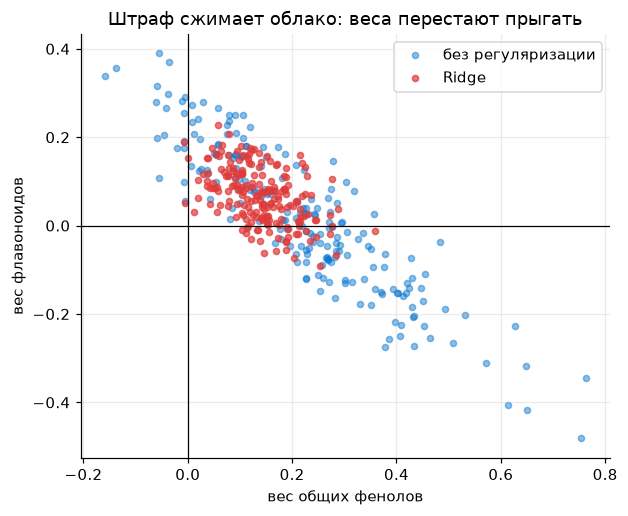

разброс весов без регуляризации: [0.167 0.163]
разброс весов с Ridge:           [0.063 0.062]


In [39]:
pair_ridge = np.array([Ridge(alpha=30).fit(pair[i], y_train[i]).coef_ for i in boot_idx])

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.scatter(pair_ols[:, 0], pair_ols[:, 1], s=16, color="#0072CE", alpha=0.45, label="без регуляризации")
ax.scatter(pair_ridge[:, 0], pair_ridge[:, 1], s=16, color="#E03A3A", alpha=0.7, label="Ridge")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("вес общих фенолов")
ax.set_ylabel("вес флавоноидов")
ax.set_title("Штраф сжимает облако: веса перестают прыгать")
ax.legend()
plt.show()

print("разброс весов без регуляризации:", np.round(pair_ols.std(axis=0), 3))
print("разброс весов с Ridge:          ", np.round(pair_ridge.std(axis=0), 3))

### Как выбрать силу штрафа

`alpha` — гиперпараметр, по обучающим данным его не выучить: чем меньше штраф,
тем меньше ошибка на обучении, и на обучающей выборке всегда победит ноль.
Подбирать его надо по данным, которых модель не видела. Тестовую выборку для
этого трогать нельзя, поэтому используем кросс-валидацию на обучающей.

In [40]:
alphas = [0.01, 0.1, 1, 3, 10, 30, 100, 300]
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = {}
for alpha in alphas:
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    folds = cross_val_score(model, X_train, y_train, cv=cv,
                            scoring="neg_root_mean_squared_error")
    cv_scores[alpha] = -folds.mean()

best_alpha = min(cv_scores, key=cv_scores.get)

ridge_best = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
ridge_best.fit(X_train, y_train)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_best.predict(X_test)))

for alpha, score in cv_scores.items():
    print(f"  alpha={alpha:<6} RMSE на кросс-валидации {score:.4f}")
print(f"лучший alpha: {best_alpha}, RMSE на тесте {ridge_rmse:.3f}")

  alpha=0.01   RMSE на кросс-валидации 0.6233
  alpha=0.1    RMSE на кросс-валидации 0.6230
  alpha=1      RMSE на кросс-валидации 0.6205
  alpha=3      RMSE на кросс-валидации 0.6164
  alpha=10     RMSE на кросс-валидации 0.6097
  alpha=30     RMSE на кросс-валидации 0.6098
  alpha=100    RMSE на кросс-валидации 0.6389
  alpha=300    RMSE на кросс-валидации 0.7014
лучший alpha: 10, RMSE на тесте 0.439


In [41]:
# --- проверка ---

# 1. посчитаны все значения alpha
assert set(cv_scores) == set(alphas), "посчитаны не все значения alpha"

# 2. RMSE положительный: если отрицательный, забыли развернуть знак
assert all(score > 0 for score in cv_scores.values()), (
    "sklearn возвращает neg_root_mean_squared_error со знаком минус"
)

# 3. лучший alpha действительно дает минимум
assert cv_scores[best_alpha] == min(cv_scores.values()), "best_alpha не соответствует минимуму"

# 4. слишком сильный штраф хуже лучшего: модель задавили
assert cv_scores[300] > cv_scores[best_alpha], "самый сильный штраф не должен быть лучшим"

# 5. на тесте результат в том же районе, что у обычной регрессии
assert abs(ridge_rmse - full_rmse) < 0.1, "RMSE на тесте подозрительно далек от обычной регрессии"

print("проверки пройдены")

проверки пройдены


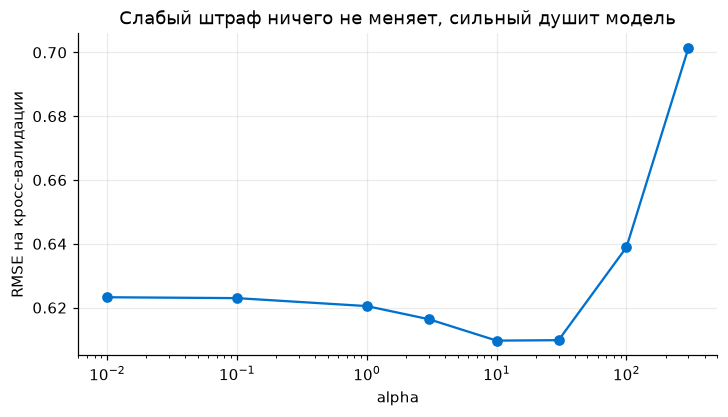

In [42]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(list(cv_scores), list(cv_scores.values()), "o-", color="#0072CE")
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("RMSE на кросс-валидации")
ax.set_title("Слабый штраф ничего не меняет, сильный душит модель")
plt.show()

Кривая почти плоская до десяти-тридцати и резко растет дальше. Соседние
значения `alpha` отличаются в четвертом знаке, и честно сказать, какое из них
лучше, по таким данным нельзя: это разница в пределах шума. Главный эффект
регуляризации здесь не в качестве, а в устойчивости весов.

### Как штраф меняет веса

Посмотрим, что происходит со всеми двенадцатью весами при усилении штрафа.
Слева L2, справа L1.

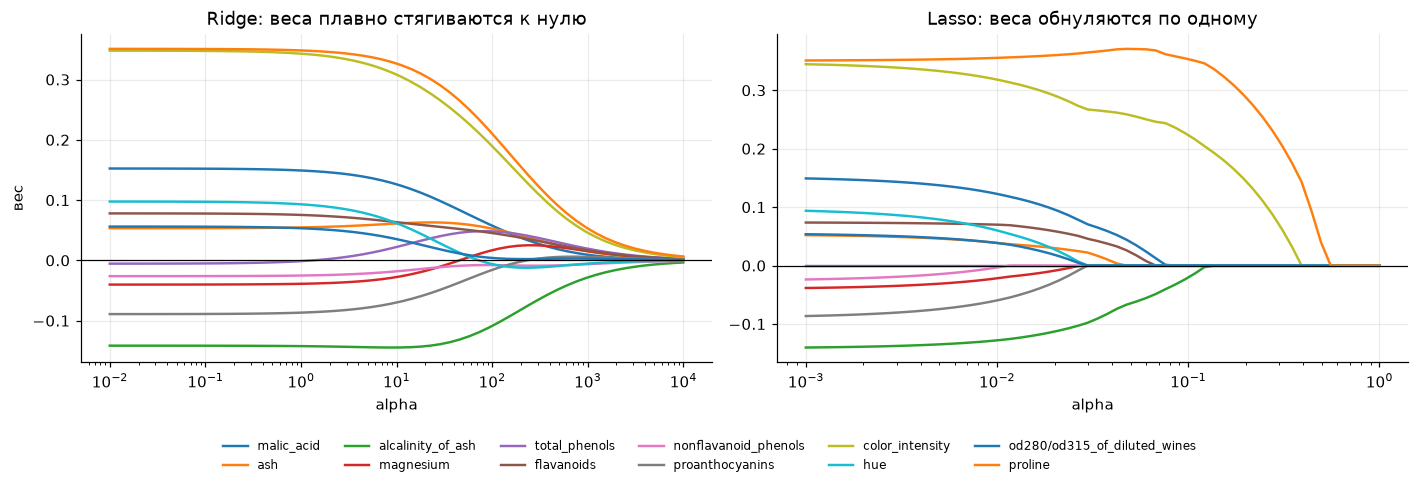

Lasso с alpha=0.05 обнулил: ['ash', 'magnesium', 'total_phenols', 'nonflavanoid_phenols', 'proanthocyanins', 'hue', 'od280/od315_of_diluted_wines']


In [43]:
ridge_alphas = np.logspace(-2, 4, 60)
lasso_alphas = np.logspace(-3, 0, 60)

ridge_path = np.array([Ridge(alpha=a).fit(X_train_std, y_train).coef_ for a in ridge_alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=20000).fit(X_train_std, y_train).coef_ for a in lasso_alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, path, grid_alphas, title in [
    (axes[0], ridge_path, ridge_alphas, "Ridge: веса плавно стягиваются к нулю"),
    (axes[1], lasso_path, lasso_alphas, "Lasso: веса обнуляются по одному"),
]:
    for j, name in enumerate(feature_names):
        ax.plot(grid_alphas, path[:, j], lw=1.6, label=name)
    ax.set_xscale("log")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("alpha")
    ax.set_title(title)
axes[0].set_ylabel("вес")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, fontsize=8, frameon=False)
plt.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

lasso_example = Lasso(alpha=0.05, max_iter=20000).fit(X_train_std, y_train)
zeroed = [name for name, value in zip(feature_names, lasso_example.coef_) if value == 0]
print("Lasso с alpha=0.05 обнулил:", zeroed)

Итог двух последних разделов: функция потерь и штраф — это предположения
о данных, записанные формулой.

| предположение | что минимизируем | метод |
|---|---|---|
| нормальный шум | сумма квадратов остатков | линейная регрессия |
| шум Лапласа | сумма модулей остатков | медианная регрессия |
| нормальное априорное на веса | штраф L2 | `Ridge` |
| априорное Лапласа на веса | штраф L1 | `Lasso` |

На следующем занятии ответ будет не числом, а классом. Шум тогда описывается
распределением Бернулли, и та же логика дает логистическую регрессию.

## 11. Что запомнить

**Нормальное уравнение** дает веса одной формулой. Геометрически предсказание —
проекция вектора ответов на пространство признаков, остатки перпендикулярны
всем признакам.

**Градиентный спуск** нужен, когда формула слишком дорогая или ее нет,
и требует одинакового масштаба признаков.

**Метрики.** RMSE — в единицах целевой переменной и чувствителен к грубым
ошибкам, MAE — устойчивее к выбросам, R² — доля объясненного разброса.

**Веса можно сравнивать** только после стандартизации, и даже тогда осторожно:
при мультиколлинеарности вклад связанных признаков делится случайно.
Стандартизация заодно делает точным обращение матрицы в нормальном уравнении.

**Регуляризация** стабилизирует веса ценой небольшого смещения, L1 к тому же
обнуляет часть весов. Силу штрафа подбирают по кросс-валидации, а не по тесту.

**Метод наименьших квадратов** — это метод максимального правдоподобия при
нормальном шуме, а штрафы L2 и L1 — априорные распределения на веса. Функция
потерь и штраф — предположения о данных, а не прихоть.

## К следующему занятию

1. Посмотреть лекцию [Linear Classification & Logistic Regression](https://www.youtube.com/watch?v=_SUJsDLtJsE&list=PL4_hYwCyhAvZyW6qS58x4uElZgAkMVUvj) Лектория ФПМИ — обязательно
2. Посмотреть первую половину лекции [SVM. PCA](https://www.youtube.com/watch?v=C9nop0dgJc4&list=PL4_hYwCyhAvZyW6qS58x4uElZgAkMVUvj), до PCA
3. Сделать лабораторную: она целиком домашняя, прислать преподавателю в личные сообщения до 19 сентября